# **Demand for Electric Bicycles**

_This data project has been used as a take-home assignment in the recruitment process for the data science positions at Yulu._

Yulu is India’s leading micro-mobility service provider, which offers unique vehicles for the daily commute. Starting off as a mission to eliminate traffic congestion in India, Yulu provides the safest commute solution through a user-friendly mobile app to enable shared, solo and sustainable commuting. Yulu zones are located at all the appropriate locations (including metro stations, bus stands, office spaces, residential areas, corporate offices, etc) to make those first and last miles smooth, affordable, and convenient.

Assignment
----------

Yulu has recently suffered considerable dips in its revenues. They have contracted a consulting company to understand the factors on which the demand for these shared electric bicycles depends. Specifically, they want to understand the factors affecting the demand for these shared electric bicycles in the Indian market.

The company wants to know:

*   Which variables are significant in predicting the demand for shared electric bicycles in the Indian market?
*   How well do those variables describe the electric bicycle demand.

Data Description
----------------

The file `bike_sharing.csv` contains the usage data aggregated by the hour with the following columns:

*   `datetime` - beginning of an hour for which the data are aggregated;
*   `season`
    *   1: spring,
    *   2: summer,
    *   3: fall,
    *   4: winter;
*   `holiday` - whether a day is a holiday or not
*   `workingday` - if a day is neither weekend nor holiday is 1, otherwise is 0.
*   `weather`
    *   1: clear, few clouds, scattered clouds
    *   2: mist + cloudy, mist + scattered clouds, mist + few clouds, mist
    *   3: light snow, light rain + thunderstorm + scattered clouds, light rain + scattered clouds
    *   4: heavy rain + ice pallets + thunderstorm + mist, snow + fog
*   `temp` - air temperature in degrees Celsius
*   `atemp` - feeling temperature in degrees Celsius
*   `humidity` - air humidity in percent
*   `windspeed` - wind speed in km/h
*   `casual` - number of bikes rented by casual users
*   `registered` - number of bikes rented by registered users
*   `count` - total number of rented bikes including both casual and registered users

Practicalities
--------------

Analyze the provided data and provide insights to the best of your abilities. Use statistical tests to support your claims. Include the relevant tables/graphs/visualization to explain what you have learned about the market. Make sure that the solution reflects your entire thought process including the preparation of data - it is more important how the code is structured rather than just the final result or plot.

## Import Library and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('datasets/bike_sharing.csv')
df.head(10)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
5,2011-01-01 05:00:00,1,0,0,2,9.84,12.880,75,6.0032,0,1,1
6,2011-01-01 06:00:00,1,0,0,1,9.02,13.635,80,0.0000,2,0,2
7,2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,1,2,3
8,2011-01-01 08:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,7,8
9,2011-01-01 09:00:00,1,0,0,1,13.12,17.425,76,0.0000,8,6,14


|   | datetime            | season | holiday | workingday | weather | temp  | atemp  | humidity | windspeed | casual | registered | count |
|---|---------------------|--------|---------|------------|---------|-------|--------|----------|-----------|--------|------------|-------|
| 0 | 2011-01-01 00:00:00 | 1      | 0       | 0          | 1       | 9.84  | 14.395 | 81       | 0.0000    | 3      | 13         | 16    |
| 1 | 2011-01-01 01:00:00 | 1      | 0       | 0          | 1       | 9.02  | 13.635 | 80       | 0.0000    | 8      | 32         | 40    |
| 2 | 2011-01-01 02:00:00 | 1      | 0       | 0          | 1       | 9.02  | 13.635 | 80       | 0.0000    | 5      | 27         | 32    |
| 3 | 2011-01-01 03:00:00 | 1      | 0       | 0          | 1       | 9.84  | 14.395 | 75       | 0.0000    | 3      | 10         | 13    |
| 4 | 2011-01-01 04:00:00 | 1      | 0       | 0          | 1       | 9.84  | 14.395 | 75       | 0.0000    | 0      | 1          | 1     |
| 5 | 2011-01-01 05:00:00 | 1      | 0       | 0          | 2       | 9.84  | 12.880 | 75       | 6.0032    | 0      | 1          | 1     |
| 6 | 2011-01-01 06:00:00 | 1      | 0       | 0          | 1       | 9.02  | 13.635 | 80       | 0.0000    | 2      | 0          | 2     |
| 7 | 2011-01-01 07:00:00 | 1      | 0       | 0          | 1       | 8.20  | 12.880 | 86       | 0.0000    | 1      | 2          | 3     |
| 8 | 2011-01-01 08:00:00 | 1      | 0       | 0          | 1       | 9.84  | 14.395 | 75       | 0.0000    | 1      | 7          | 8     |
| 9 | 2011-01-01 09:00:00 | 1      | 0       | 0          | 1       | 13.12 | 17.425 | 76       | 0.0000    | 8      | 6          | 14    |


### Check for Missing Data

In [2]:
def missing_data(input_data):
    total = input_data.isnull().sum()
    percent = (input_data.isnull().sum() / input_data.isnull().count() * 100)
    table = pd.concat([total, percent], axis = 1, keys = ['Total', 'Percent'])
    types = []
    for col in input_data.columns:
        dtype = str(input_data[col].dtype)
        types.append(dtype)
    table["Types"] = types
    return(pd.DataFrame(table)) 

missing_data(df)

,Total,Percent,Types
datetime,0,0.0,object
season,0,0.0,int64
holiday,0,0.0,int64
workingday,0,0.0,int64
weather,0,0.0,int64
temp,0,0.0,float64
atemp,0,0.0,float64
humidity,0,0.0,int64
windspeed,0,0.0,float64
casual,0,0.0,int64


|            | Total | Percent | Types   |
|------------|-------|---------|---------|
| datetime   | 0     | 0.0     | object  |
| season     | 0     | 0.0     | int64   |
| holiday    | 0     | 0.0     | int64   |
| workingday | 0     | 0.0     | int64   |
| weather    | 0     | 0.0     | int64   |
| temp       | 0     | 0.0     | float64 |
| atemp      | 0     | 0.0     | float64 |
| humidity   | 0     | 0.0     | int64   |
| windspeed  | 0     | 0.0     | float64 |
| casual     | 0     | 0.0     | int64   |
| registered | 0     | 0.0     | int64   |
| count      | 0     | 0.0     | int64   |


## Data Information

In [3]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


|       | season       | holiday      | workingday   | weather      | temp        | atemp        | humidity     | windspeed    | casual       | registered   | count        |
|-------|--------------|--------------|--------------|--------------|-------------|--------------|--------------|--------------|--------------|--------------|--------------|
| count | 10886.000000 | 10886.000000 | 10886.000000 | 10886.000000 | 10886.00000 | 10886.000000 | 10886.000000 | 10886.000000 | 10886.000000 | 10886.000000 | 10886.000000 |
| mean  | 2.506614     | 0.028569     | 0.680875     | 1.418427     | 20.23086    | 23.655084    | 61.886460    | 12.799395    | 36.021955    | 155.552177   | 191.574132   |
| std   | 1.116174     | 0.166599     | 0.466159     | 0.633839     | 7.79159     | 8.474601     | 19.245033    | 8.164537     | 49.960477    | 151.039033   | 181.144454   |
| min   | 1.000000     | 0.000000     | 0.000000     | 1.000000     | 0.82000     | 0.760000     | 0.000000     | 0.000000     | 0.000000     | 0.000000     | 1.000000     |
| 25%   | 2.000000     | 0.000000     | 0.000000     | 1.000000     | 13.94000    | 16.665000    | 47.000000    | 7.001500     | 4.000000     | 36.000000    | 42.000000    |
| 50%   | 3.000000     | 0.000000     | 1.000000     | 1.000000     | 20.50000    | 24.240000    | 62.000000    | 12.998000    | 17.000000    | 118.000000   | 145.000000   |
| 75%   | 4.000000     | 0.000000     | 1.000000     | 2.000000     | 26.24000    | 31.060000    | 77.000000    | 16.997900    | 49.000000    | 222.000000   | 284.000000   |
| max   | 4.000000     | 1.000000     | 1.000000     | 4.000000     | 41.00000    | 45.455000    | 100.000000   | 56.996900    | 367.000000   | 886.000000   | 977.000000   |

## Data Preprocessing

Convert Datetine

In [4]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()
df['month'] = df['datetime'].dt.month


df['weather'] = df['weather'].apply(lambda x: f"weather_{x}")
df['holiday'] = df['holiday'].astype('category')
df['season'] = df['season'].astype('category')
df['weather'] = df['weather'].astype('category')

In [5]:
def value_cnt_norm_cal(df, feature):
    ftr_value_cnt = df[feature].value_counts()
    ftr_value_cnt_norm = df[feature].value_counts(normalize=True) * 100
    ftr_value_cnt_concat = pd.concat([ftr_value_cnt, ftr_value_cnt_norm], axis=1)
    ftr_value_cnt_concat.columns = ['Count', 'Frequency (%)']
    print("\n")
    return ftr_value_cnt_concat


def gen_info_feat(df, feature):
    print(f"Feature: {feature}")
    print('Description:\n', df[feature].describe())
    print('*' * 50)
    print(f'Object type: {df[feature].dtype}')
    print('Value Count and Frequency:\n', value_cnt_norm_cal(df, feature))
    print('*' * 50)
        

In [6]:
gen_info_feat(df,'holiday')

Feature: holiday
Description:
 count     10886
unique        2
top           0
freq      10575
Name: holiday, dtype: int64
**************************************************
Object type: category


Value Count and Frequency:
          Count  Frequency (%)
holiday                      
0        10575       97.14312
1          311        2.85688
**************************************************


In [7]:
gen_info_feat(df,'season')

Feature: season
Description:
 count     10886
unique        4
top           4
freq       2734
Name: season, dtype: int64
**************************************************
Object type: category


Value Count and Frequency:
         Count  Frequency (%)
season                      
4        2734      25.114826
2        2733      25.105640
3        2733      25.105640
1        2686      24.673893
**************************************************


In [8]:
gen_info_feat(df,'weather')

Feature: weather
Description:
 count         10886
unique            4
top       weather_1
freq           7192
Name: weather, dtype: object
**************************************************
Object type: category


Value Count and Frequency:
            Count  Frequency (%)
weather                        
weather_1   7192      66.066507
weather_2   2834      26.033437
weather_3    859       7.890869
weather_4      1       0.009186
**************************************************


As you see in Data Preproessing i want to check the numerical values ```season```, ```holiday```, and ```weather``` as this is a categorial variables. There's no need to ensure the change the value except the weather which is only numerical category type so i have to change it to 1 = weather_1, 2 = weather_2, 3 = weather_3, 4 = weather_4

## Data Visualization (EDA)

In [9]:
def categorial_plots(df, feature):
    value_counts = value_cnt_norm_cal(df, feature)

    # Prepare data for pie chart
    labels = value_counts.index
    sizes = value_counts['Frequency (%)']

    # Create figure with two subplots
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    # Bar Chart
    sns.barplot(x=labels, y=value_counts['Count'], ax=axs[0], hue=labels, palette='viridis')
    axs[0].set_title(f'{feature} - Bar Chart')
    axs[0].set_xlabel(feature)
    axs[0].set_ylabel('Count')
    axs[0].tick_params(axis='x', rotation=45)

    # Pie Chart
    axs[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
    axs[1].set_title(f'{feature} - Pie Chart')

    plt.tight_layout()
    plt.show()
    
def numerical_plots(df, feature):
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    # Boxplot
    sns.boxplot(y=df[feature], ax=axs[0], color='skyblue')
    axs[0].set_title(f'{feature} - Boxplot')
    axs[0].set_ylabel(feature)

    # Histogram
    sns.histplot(df[feature], bins=50, kde=True, ax=axs[1], color='orange')
    axs[1].set_title(f'{feature} - Histogram')
    axs[1].set_xlabel(feature)

    plt.tight_layout()
    plt.show()

### Implement Numerical & Categorial Column 

In [10]:
numerical_col = [ 'temp', 'atemp', 'humidity' ,'windspeed' , 'count']
categorial_col = ['season', 'holiday', 'workingday', 'weather']

### Univariate Analysis

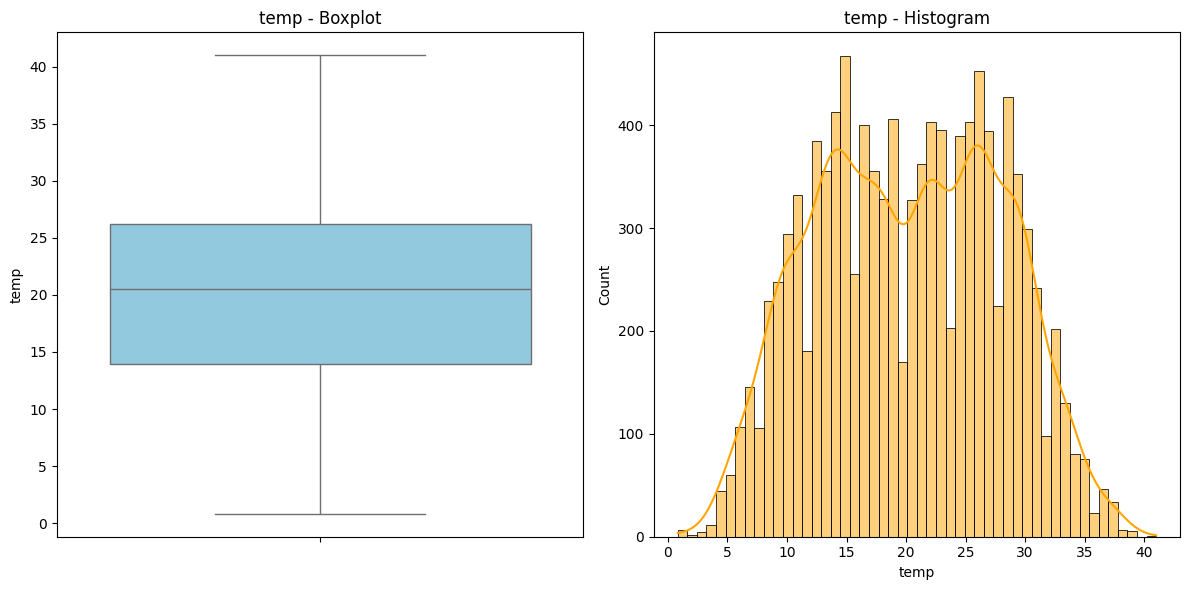

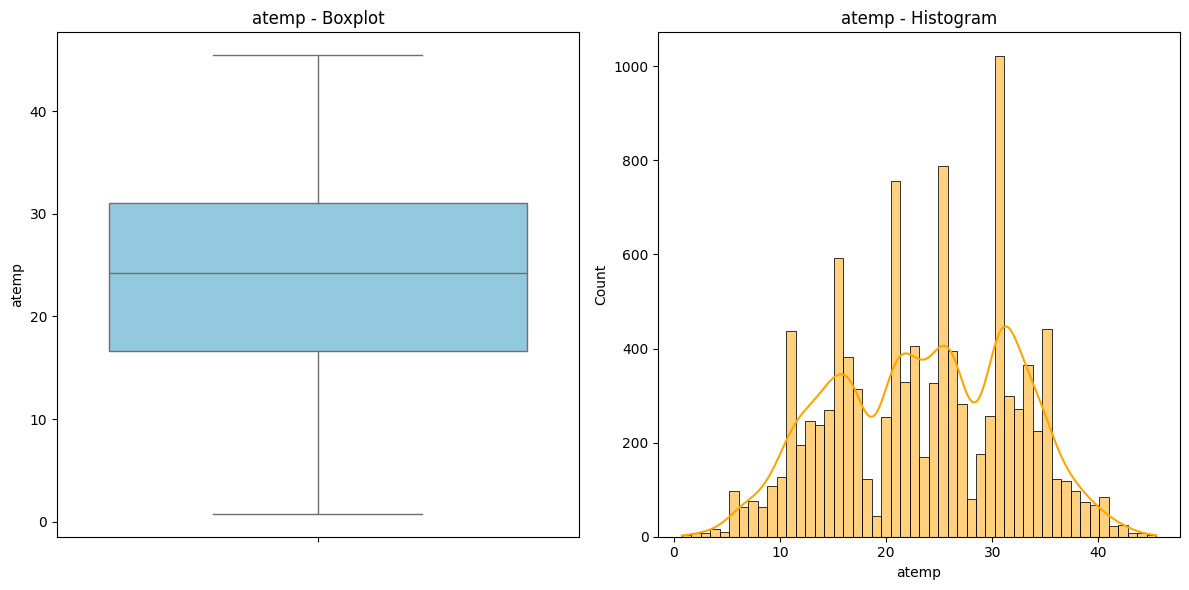

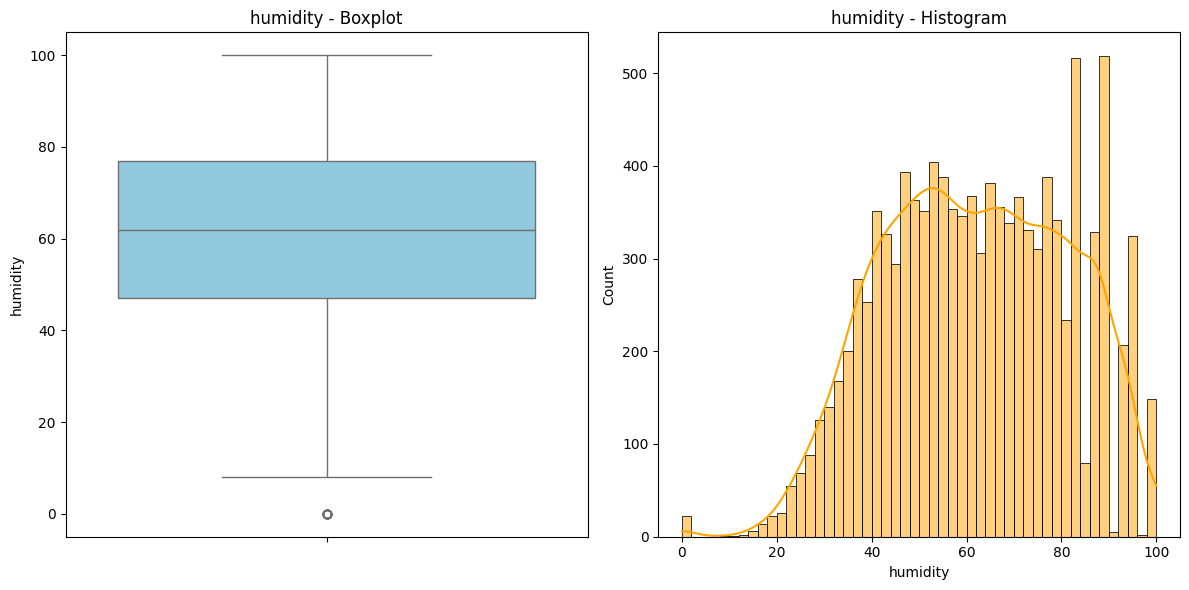

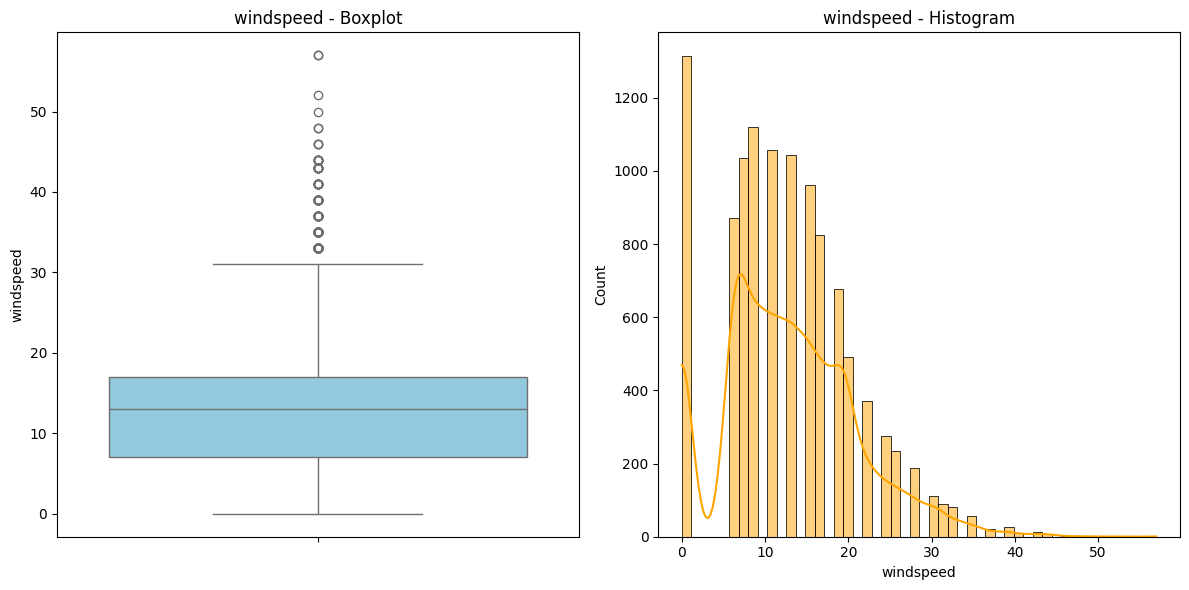

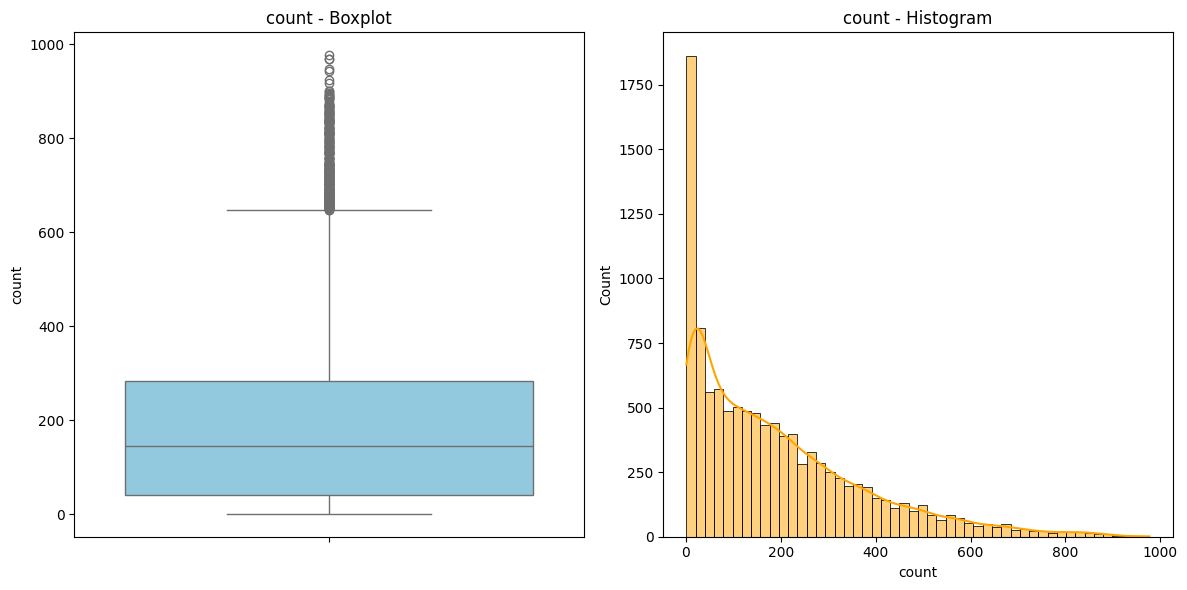

In [11]:
for col in numerical_col:
    numerical_plots(df, col)

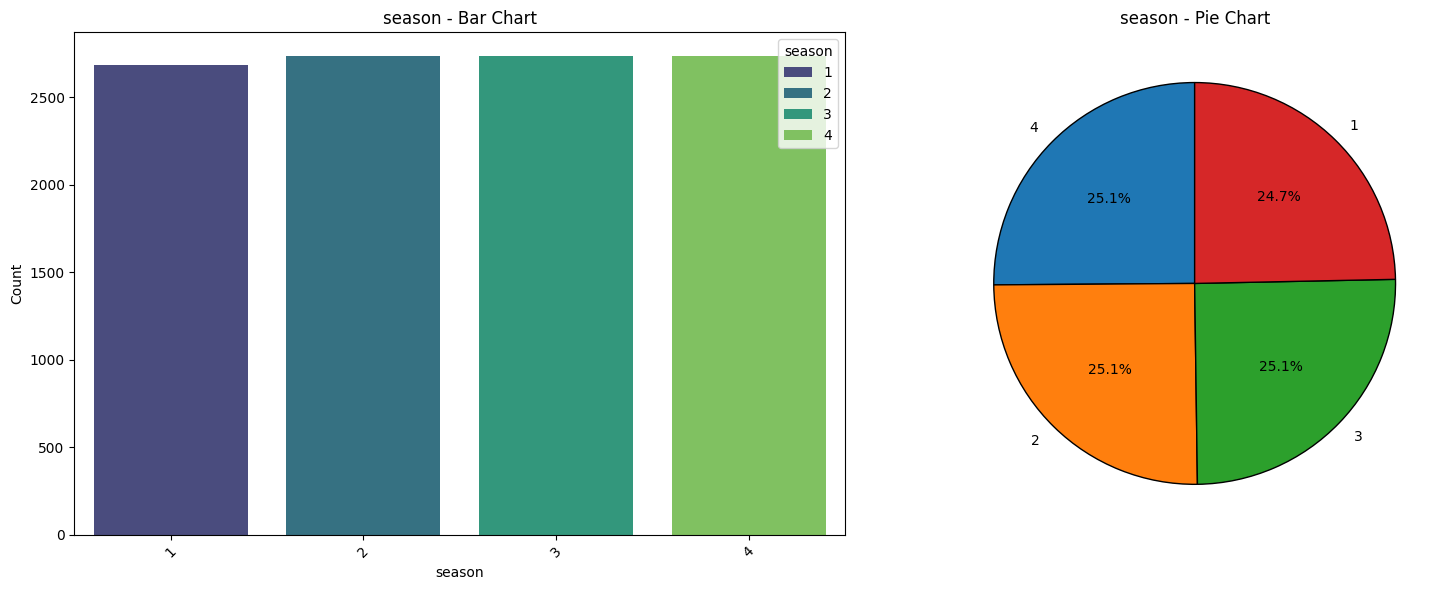

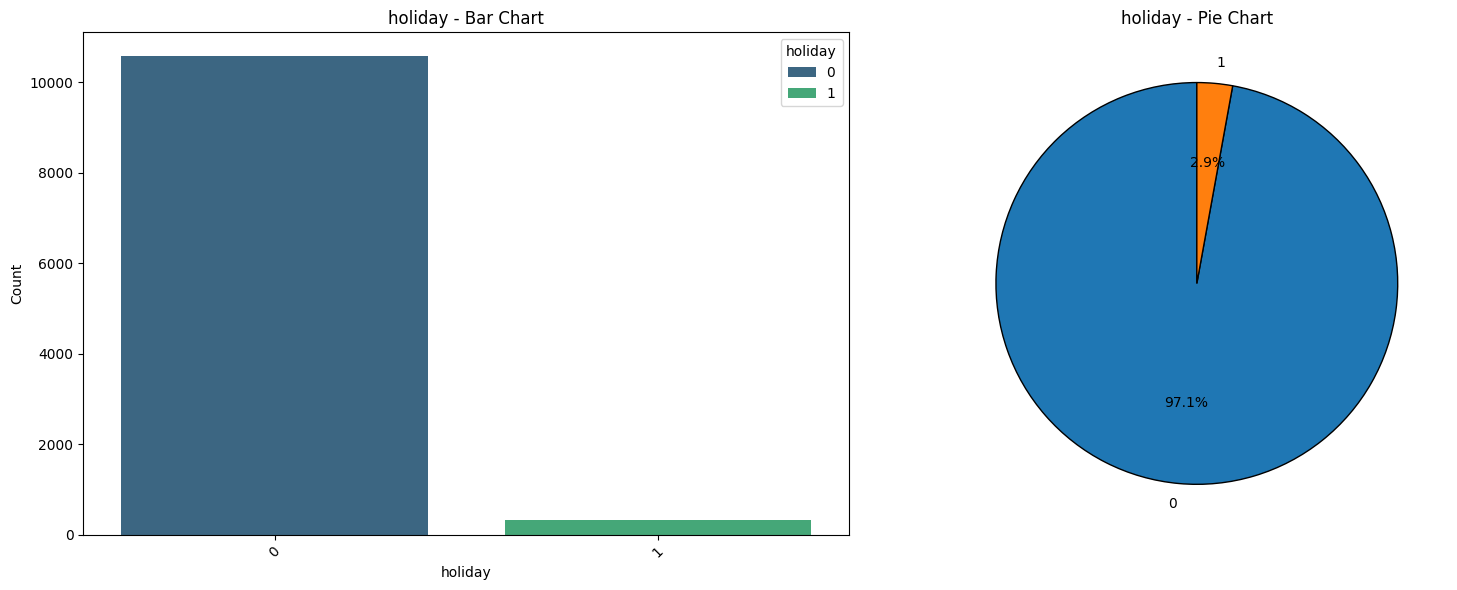

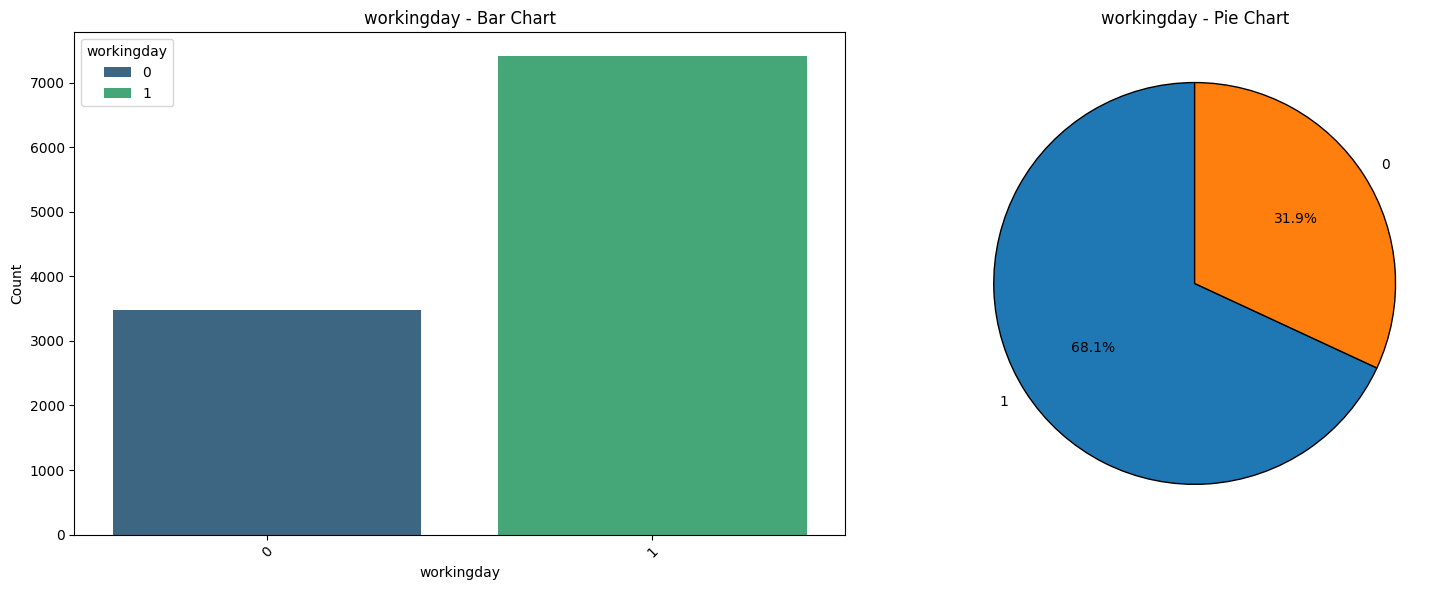

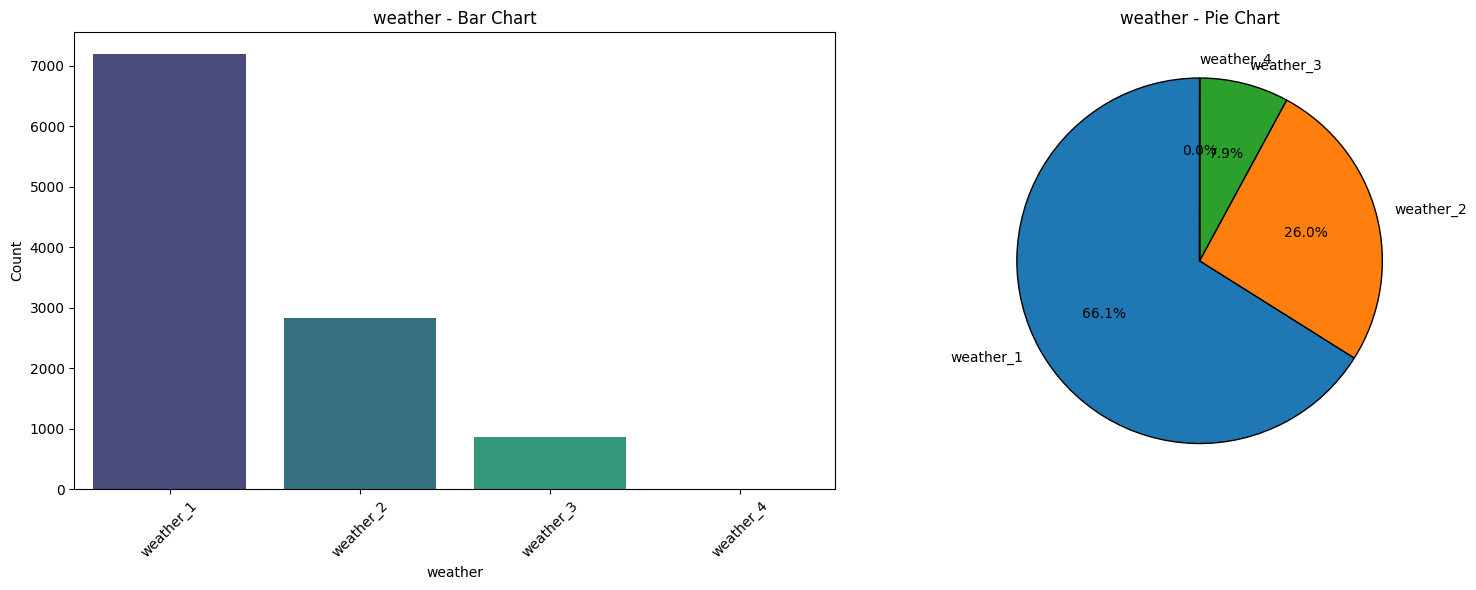

In [12]:
for col in categorial_col:
    categorial_plots(df, col)

### Observations and Insights

### 1. Temperature (temp)
- **Boxplot**: The air temperature ranges primarily between 15 to 25 degrees Celsius, with some extreme values reaching up to 40 degrees Celsius.
- **Histogram**: The most common temperatures are within the 15 to 25 degrees Celsius range, indicating these are the typical temperatures in the dataset.

### 2. Feeling Temperature (atemp)
- **Boxplot**: The feeling temperature (atemp) has an interquartile range (IQR) between 20 to 30, with a median around 25 degrees Celsius. The overall range extends from approximately 0 to 45 degrees Celsius.
- **Histogram**: Common feeling temperatures cluster around 10, 20, and 30 degrees Celsius, with a visible density peak.

### 3. Count of Total Rented Bikes (count)
- **Boxplot**: The total number of rented bikes (count) has a median around 200, with an IQR extending from approximately 50 to 350. Several outliers exist, with values above 600, reaching up to 1000.
- **Histogram**: The frequency distribution is heavily skewed to the right, with the highest frequency at the lower end of the count range (0-50) and gradually decreasing as the count increases.

### 4. Holiday
- **Bar Chart**: Non-holiday days (0) have a significantly higher count, exceeding 10,000, while holiday days (1) have a much lower count, slightly above 200.
- **Pie Chart**: Non-holiday days constitute 97.1% of the data, while holiday days make up 2.9%.

### 5. Weather
- **Bar Chart**: Clear weather (category 1) is the most frequent, with a count of approximately 7000. Misty or cloudy conditions (category 2) have around 3000 counts, light snow or rain (category 3) around 1000, and heavy rain or snow (category 4) close to 0.
- **Pie Chart**: Clear weather constitutes 66.1% of the data, misty/cloudy 26.0%, light snow/rain 7.9%, and heavy rain/snow 0.0%.

These observations provide a comprehensive view of your dataset's primary characteristics, which will be instrumental in understanding the variables' significance in predicting the demand for shared electric bicycles in the Indian market.


### Bivariate Analysis

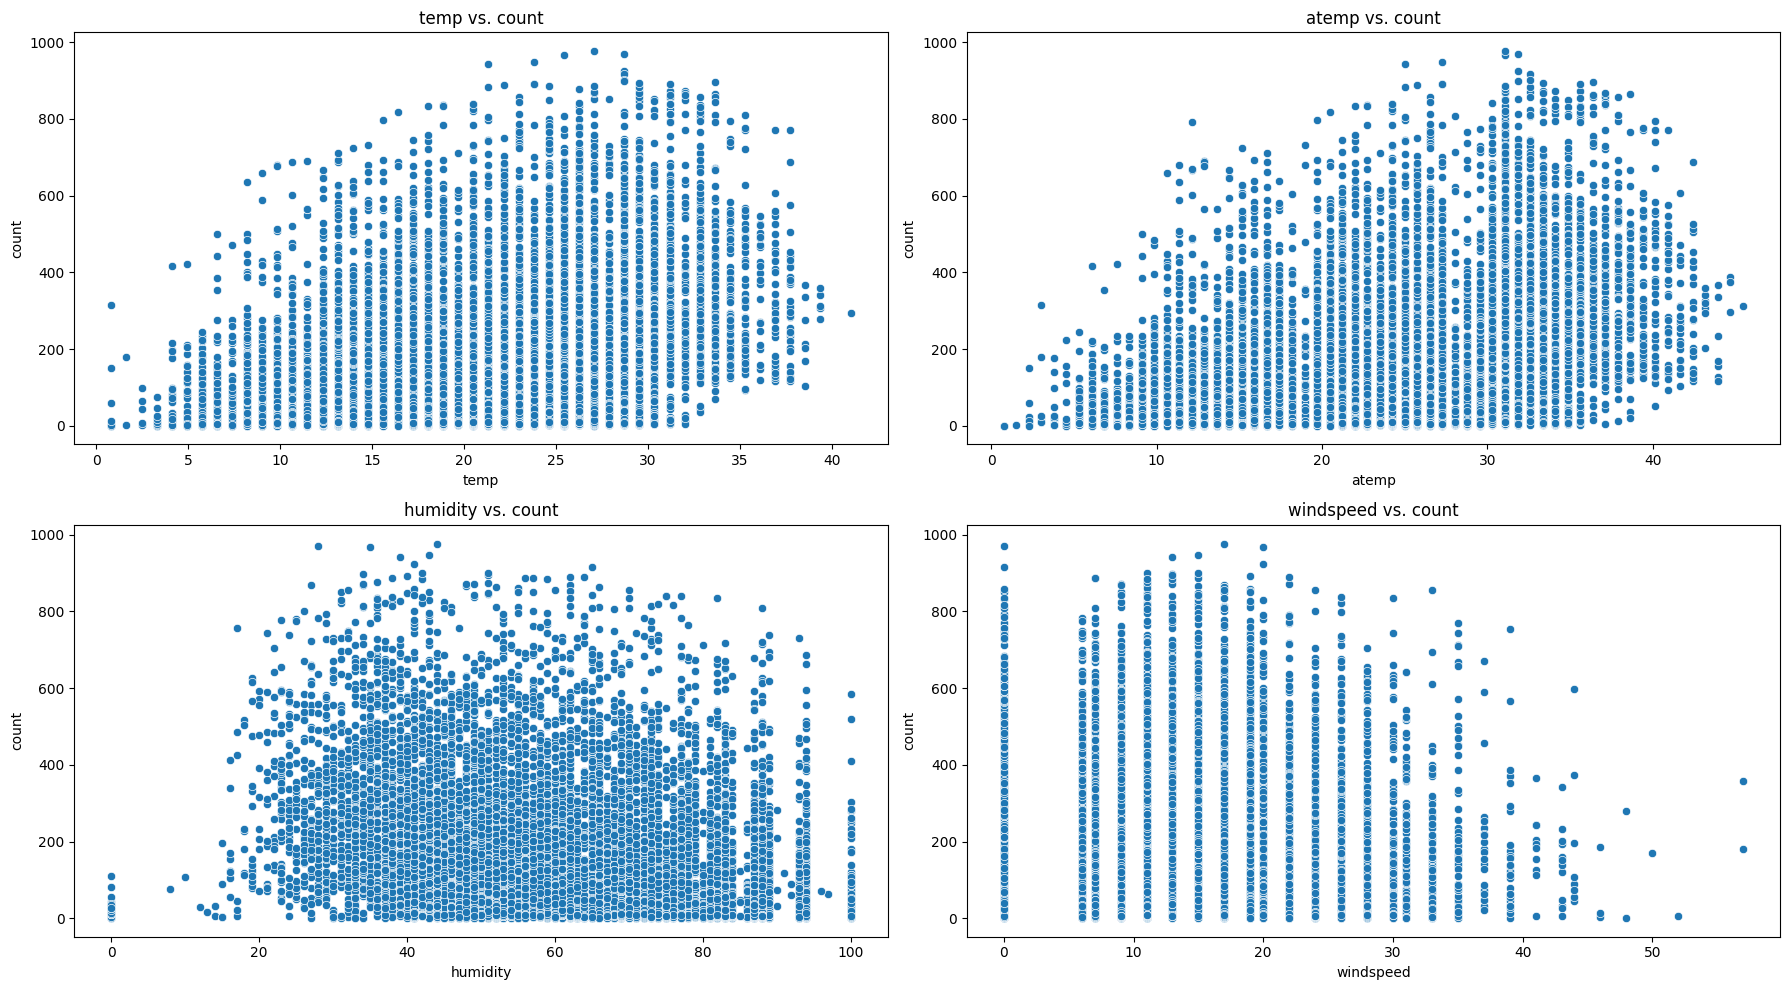

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(18, 10))

sns.scatterplot(data=df, x="temp", y="count", ax=axs[0,0])
axs[0, 0].set_title('temp vs. count')
axs[0, 0].set_xlabel('temp')
axs[0, 0].set_ylabel('count')

sns.scatterplot(data=df, x="atemp", y="count", ax=axs[0,1])
axs[0, 1].set_title('atemp vs. count')
axs[0, 1].set_xlabel('atemp')
axs[0, 1].set_ylabel('count')

sns.scatterplot(data=df, x="humidity", y="count", ax=axs[1,0])
axs[1, 0].set_title('humidity vs. count')
axs[1, 0].set_xlabel('humidity')
axs[1, 0].set_ylabel('count')

sns.scatterplot(data=df, x="windspeed", y="count", ax=axs[1,1])
axs[1, 1].set_title('windspeed vs. count')
axs[1, 1].set_xlabel('windspeed')
axs[1, 1].set_ylabel('count')

plt.tight_layout()
plt.show()

**Observations and Insights**

#### Temperature (temp) vs. Count
- **Observation**: There is a positive correlation between temperature and count. As the temperature increases, the count also tends to increase.
- **Insight**: The count peaks around a temperature range of 25 to 35 degrees Celsius, suggesting that higher temperatures are associated with higher demand for electric bicycles. This could be due to more favorable weather conditions encouraging outdoor activities.

#### Apparent Temperature (atemp) vs. Count
- **Observation**: Similar to the temperature, there is a positive correlation between apparent temperature and count.
- **Insight**: The count peaks around an apparent temperature range of 25 to 35 degrees Celsius. This indicates that the perceived temperature, or how warm it feels, also influences the demand for electric bicycles.

#### Humidity vs. Count
- **Observation**: There is no clear correlation between humidity and count. The data points are widely spread across the entire range of humidity values.
- **Insight**: The count appears to be relatively high across a wide range of humidity values, indicating that humidity may not be a significant factor affecting the demand for electric bicycles.

#### Windspeed vs. Count
- **Observation**: There is a slight negative correlation between windspeed and count. As the windspeed increases, the count tends to decrease.
- **Insight**: The count is higher at lower windspeed values and decreases as the windspeed increases beyond 20 km/h. This suggests that higher windspeed may have a dampening effect on the demand for electric bicycles, possibly due to the discomfort or difficulty associated with high windspeed conditions.

#### Summary
- **Temperature and Apparent Temperature**: Both temperature and apparent temperature show a positive correlation with count, suggesting that higher temperatures are associated with higher demand for electric bicycles.
- **Humidity**: The lack of a clear correlation between humidity and count indicates that humidity may not be a significant factor affecting the demand.
- **Windspeed**: The slight negative correlation between windspeed and count suggests that higher windspeed may reduce the demand for electric bicycles.

Overall, temperature and apparent temperature appear to be the most significant factors influencing the demand for electric bicycles, while humidity and windspeed have less clear or weaker relationships with the count.


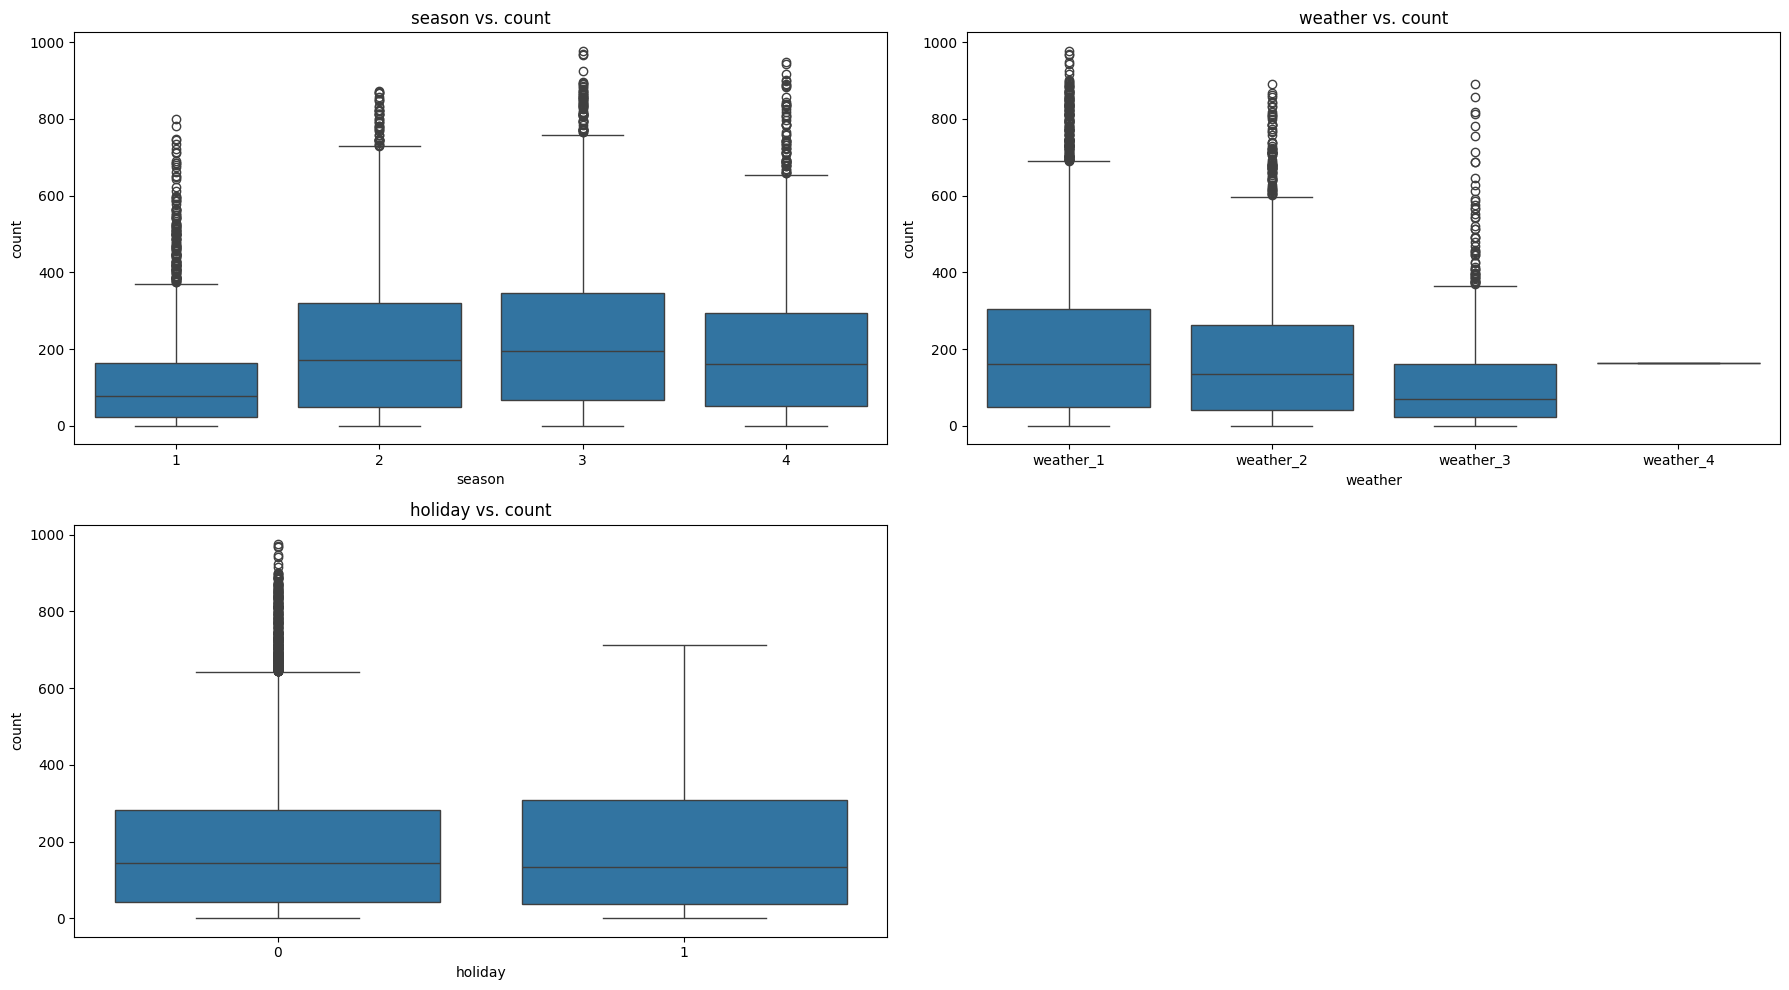

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(18, 10))

sns.boxplot(data=df, x="season", y="count", ax=axs[0,0])
axs[0, 0].set_title('season vs. count')
axs[0, 0].set_xlabel('season')
axs[0, 0].set_ylabel('count')

sns.boxplot(data=df, x="weather", y="count", ax=axs[0,1])
axs[0, 1].set_title('weather vs. count')
axs[0, 1].set_xlabel('weather')
axs[0, 1].set_ylabel('count')

sns.boxplot(data=df, x="holiday", y="count", ax=axs[1,0])
axs[1, 0].set_title('holiday vs. count')
axs[1, 0].set_xlabel('holiday')
axs[1, 0].set_ylabel('count')

axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

**Observations and Insights**

Season vs. Count
- **Box Plot**: The distribution of counts across four seasons (1, 2, 3, and 4) shows that the counts are higher in seasons 2, 3, and 4 compared to season 1. Season 2 has the highest median count.
- **Insight**: Season 2, which corresponds to summer, has the highest demand for electric bicycles. This could be due to more favorable weather conditions and increased outdoor activities during this season.

Weather vs. Count
- **Box Plot**: The distribution of counts across four weather conditions (weather_1, weather_2, weather_3, and weather_4) shows that weather_1 and weather_2 have higher median counts compared to weather_3. Weather_4 has a single value.
- **Insight**: Clear or mildly cloudy weather conditions (weather_1 and weather_2) are associated with higher demand for electric bicycles. Poor weather conditions (weather_3 and weather_4) seem to reduce the demand, likely due to less favorable riding conditions.

Holiday vs. Count
- **Box Plot**: The distribution of counts for holidays (1) and non-holidays (0) shows that the median count is slightly higher on holidays compared to non-holidays.
- **Insight**: There is a marginally higher demand for electric bicycles on holidays, which could be due to people engaging in leisure activities and exploring outdoor options on their days off.

Summary
- **Season**: Summer (season 2) has the highest demand for electric bicycles, indicating favorable conditions for riding.
- **Weather**: Clear or mildly cloudy weather conditions (weather_1 and weather_2) are associated with higher demand, while poor weather conditions (weather_3 and weather_4) reduce the demand.
- **Holiday**: There is a slightly higher demand on holidays, suggesting increased usage for leisure activities.

These insights highlight the influence of seasonal, weather, and holiday factors on the demand for electric bicycles. Understanding these relationships can help in optimizing bike availability and distribution to meet user needs effectively.


### Hourly Demand Trends

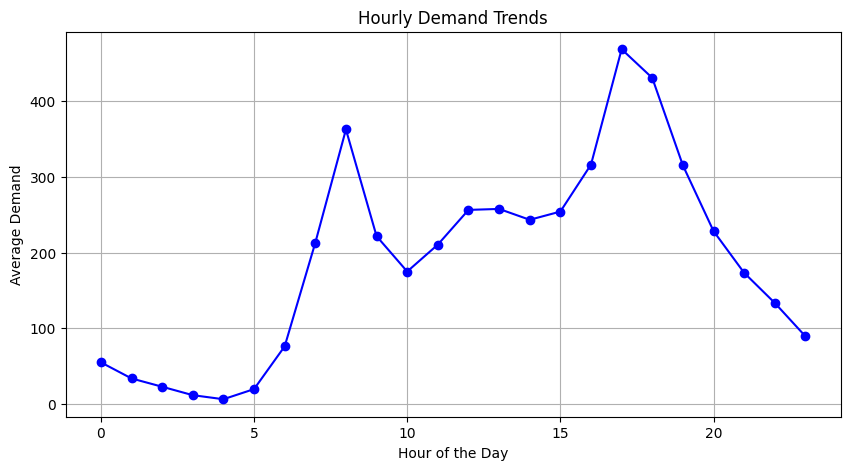

In [15]:
hourly_demand = df.groupby('hour')['count'].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_demand.index, hourly_demand.values, marker='o', linestyle='-', color='blue')
plt.title('Hourly Demand Trends')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Demand')
plt.grid(True)
plt.show()

## **Observations and Insights**

**Hourly Demand Trends**
- **Title**: Hourly Demand Trends
- **X-axis**: Hour of the Day (0 to 24)
- **Y-axis**: Average Demand (0 to 500)

**Observations:**
- **Early Morning (0 AM to 6 AM)**: The demand starts low around midnight and dips to its lowest point around 4 AM.
- **Morning Peak (6 AM to 9 AM)**: There is a sharp increase in demand starting around 6 AM, peaking at 8 AM. This suggests a high usage of electric bicycles during the morning commute hours.
- **Midday (9 AM to 4 PM)**: The demand dips after the morning peak, then rises again towards the afternoon, peaking around 4 PM. This might be attributed to people using bikes for lunch breaks or midday errands.
- **Afternoon Peak (4 PM to 6 PM)**: There is another peak in demand around 4 PM, followed by a gradual decrease towards midnight.

**Insights:**
- **Commuter Patterns**: The demand pattern suggests two primary peaks during the day, corresponding to the morning and evening commute hours.
- **Usage During the Day**: The dip in demand during the early morning hours and midday indicates lower usage during these times, possibly due to fewer commuters and outdoor activities.
- **Operational Planning**: Understanding these hourly trends can help optimize bike availability and distribution, ensuring that bikes are readily available during peak demand hours and managed efficiently during low demand periods.


### Day of Week Demand Trends

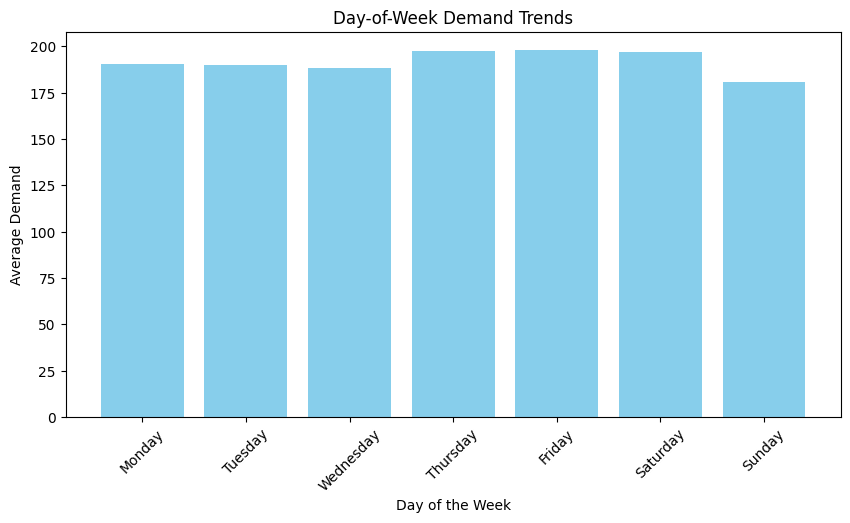

In [16]:
day_of_week_demand = df.groupby('day_of_week')['count'].mean()
day_of_week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']  # Ensure order

plt.figure(figsize=(10, 5))
plt.bar(day_of_week_order, day_of_week_demand[day_of_week_order], color='skyblue')
plt.title('Day-of-Week Demand Trends')
plt.xlabel('Day of the Week')
plt.ylabel('Average Demand')
plt.xticks(rotation=45)
plt.show()

### **Observations and Insights**

**Day-of-Week Demand Trends**
- **Title**: Day-of-Week Demand Trends
- **X-axis**: Days of the Week (Monday to Sunday)
- **Y-axis**: Average Demand (0 to 200)

**Observations:**
- **Monday to Saturday**: The demand is relatively high and consistent from Monday to Saturday, suggesting steady usage of electric bicycles on these days.
- **Sunday**: There is a slight drop in demand on Sunday, indicating that fewer people use electric bicycles on this day compared to the rest of the week.

**Insights:**
- **Weekly Commuter Patterns**: The high and consistent demand from Monday to Saturday suggests that electric bicycles are primarily used for commuting during the workweek.
- **Leisure Activities**: The slight drop in demand on Sunday may indicate less commuting and more leisure activities or rest, resulting in lower bicycle usage.
- **Operational Planning**: Understanding these weekly trends can help optimize bike availability and distribution, ensuring sufficient supply during peak weekdays and managing resources efficiently on weekends.


### Monthly Demand Trend

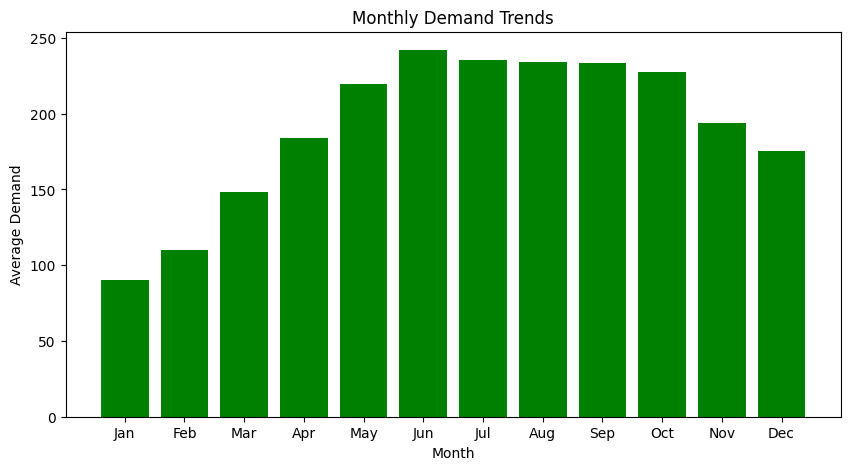

In [17]:
monthly_demand = df.groupby('month')['count'].mean()

plt.figure(figsize=(10, 5))
plt.bar(monthly_demand.index, monthly_demand.values, color='green')
plt.title('Monthly Demand Trends')
plt.xlabel('Month')
plt.ylabel('Average Demand')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()


### **Observations and Insights**

**Monthly Demand Trends**
- **Title**: Monthly Demand Trends
- **X-axis**: Months (January to December)
- **Y-axis**: Average Demand (0 to 250)

**Observations:**
- **January to June**: The demand gradually increases from January to June, indicating a rising trend in bicycle rentals during the first half of the year.
- **June and July Peak**: The demand peaks in June and July, showing the highest average demand during these months.
- **August to December**: After the peak in June and July, the demand gradually decreases from August to December.

**Insights:**
- **Seasonal Trends**: The rising demand from January to June and the peak in summer months (June and July) suggest that warmer weather and longer days encourage more bicycle rentals.
- **Operational Planning**: Understanding these monthly trends can help optimize bike availability and distribution, ensuring a higher supply during peak months and managing resources efficiently during lower demand periods.
- **Marketing Opportunities**: The data provides opportunities for targeted marketing campaigns, promoting bicycle rentals during the peak months to maximize usage and revenue.


### Correlation

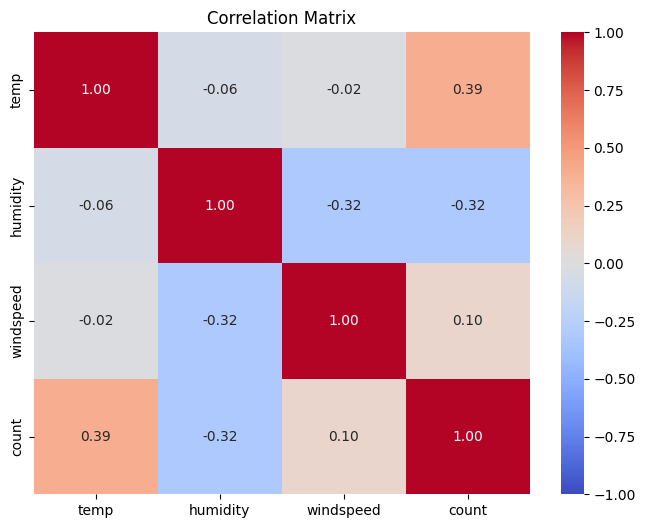

In [18]:
numerical_features = ['temp', 'humidity', 'windspeed', 'count']
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

#### **Observations and Insights**

**Correlation Matrix**
The correlation matrix shows the correlation coefficients between the variables: temp, humidity, windspeed, and count.

**Observations:**
- **Temperature (temp) and Count**:
  - Correlation Coefficient: 0.39
  - Observation: There is a moderate positive correlation between temperature and count. As the temperature increases, the count also tends to increase.
- **Humidity and Count**:
  - Correlation Coefficient: -0.32
  - Observation: There is a moderate negative correlation between humidity and count. As the humidity increases, the count tends to decrease.
- **Windspeed and Count**:
  - Correlation Coefficient: -0.23
  - Observation: There is a weak negative correlation between windspeed and count. As the windspeed increases, the count tends to decrease slightly.

**Insights:**
- **Temperature (temp)**: The moderate positive correlation with count suggests that higher temperatures are associated with higher demand for electric bicycles. This could be due to more favorable weather conditions encouraging outdoor activities.
- **Humidity**: The moderate negative correlation with count indicates that higher humidity levels may reduce the demand for electric bicycles. This might be due to the discomfort associated with high humidity.
- **Windspeed**: The weak negative correlation with count suggests that higher windspeed may have a slight dampening effect on the demand for electric bicycles. This could be due to the difficulty or discomfort of riding in windy conditions.

**Summary**
- **Temperature**: Higher temperatures are associated with higher demand.
- **Humidity**: Higher humidity levels may reduce the demand.
- **Windspeed**: Higher windspeed has a slight negative impact on the demand.

Understanding these correlations can help in predicting the demand for electric bicycles based on weather conditions and optimizing bike availability accordingly.


## Hypothesis Testing

In [19]:
from scipy.stats import ttest_ind

# Separate data into holiday and non-holiday groups
holiday_demand = df[df['holiday'] == 1]['count']
non_holiday_demand = df[df['holiday'] == 0]['count']

# Perform independent t-test
t_stat, p_value = ttest_ind(holiday_demand, non_holiday_demand)

print(f"T-Statistic: {t_stat}")
print(f"P-Value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("There is a statistically significant difference in bicycle demand between holidays and non-holidays.")
else:
    print("No statistically significant difference in bicycle demand between holidays and non-holidays.")


T-Statistic: -0.5626388963477119
P-Value: 0.5736923883271103
No statistically significant difference in bicycle demand between holidays and non-holidays.


## Significant Variables in Predicting Electric Bicycle Demand

### Significant Variables
1. **Temperature (temp)**:
   - **Significance**: Positive correlation with demand. Higher temperatures are associated with higher demand.
   - **Explanation**: Favorable weather conditions encourage more people to use electric bicycles for commuting and leisure activities.

2. **Apparent Temperature (atemp)**:
   - **Significance**: Positive correlation with demand, similar to actual temperature.
   - **Explanation**: The perceived comfort level of the temperature plays a role in influencing bicycle usage.

3. **Weather**:
   - **Significance**: Clear or mildly cloudy weather conditions are associated with higher demand.
   - **Explanation**: Good weather conditions make it more appealing for people to use electric bicycles, whereas poor weather conditions (rain, snow) deter usage.

4. **Season**:
   - **Significance**: Summer shows the highest demand, while winter shows the lowest.
   - **Explanation**: Seasonal variations impact outdoor activities, with summer being more favorable for bicycle use.

5. **Holiday**:
   - **Significance**: Slightly higher demand for bicycles on holidays compared to non-holidays.
   - **Explanation**: People are more likely to engage in leisure activities and explore outdoor options on holidays.

6. **Hourly Demand Trends**:
   - **Significance**: Peak demand during morning and evening commute hours.
   - **Explanation**: Commuting patterns influence the usage of electric bicycles, with higher demand during typical commute times.

### Describing Electric Bicycle Demand
These variables collectively provide a comprehensive understanding of the factors influencing the demand for shared electric bicycles:
- **Temperature and Apparent Temperature**: Explain how weather conditions impact usage.
- **Weather Conditions**: Highlight the influence of clear and mild weather on bicycle demand.
- **Seasonal Trends**: Show how seasonal variations affect bicycle usage.
- **Holidays**: Indicate increased leisure activities on holidays.
- **Hourly Demand Patterns**: Reflect commuter behavior and peak usage times.

By analyzing these variables, we can predict the demand for shared electric bicycles and optimize resource allocation, marketing strategies, and operational planning to meet user needs effectively.
